In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF


N = 10000
exp=42


# for exp in tqdm(range(iterations)):
data = Data()
data.generate(n=N,p=10, seed=exp)
data.generate_random_condition()

('feature_6 > -0.20284697064188606', 0.584)

In [2]:
data.df

feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64
0.496714,-0.138264,0.647689,1.52303,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.54256,2.119577,0,1.123117,0
-0.463418,-0.46573,0.241962,-1.91328,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,2.33628,1,0.023736,1
1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,5.818775,0,2.052266,2
-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.95967,-1.328186,0.196861,1.741993,1,1.396298,3
0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.76304,4.657138,0,1.520964,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.677505,-0.629625,0.051052,-1.175068,0.26315,-1.5895,-1.319203,0.3036,0.87878,0.040772,0.924394,0,1.104596,9995
1.383249,0.407372,-0.555289,1.331587,0.552332,0.483994,1.398952,-0.370326,0.664494,-0.493281,3.637353,0,2.300684,9996
0.001128,-1.047569,0.282285,0.758322,-0.079564,0.35022,-2.221678,0.452383,-1.312673,1.031308,-5.630919,0,0.301817,9997


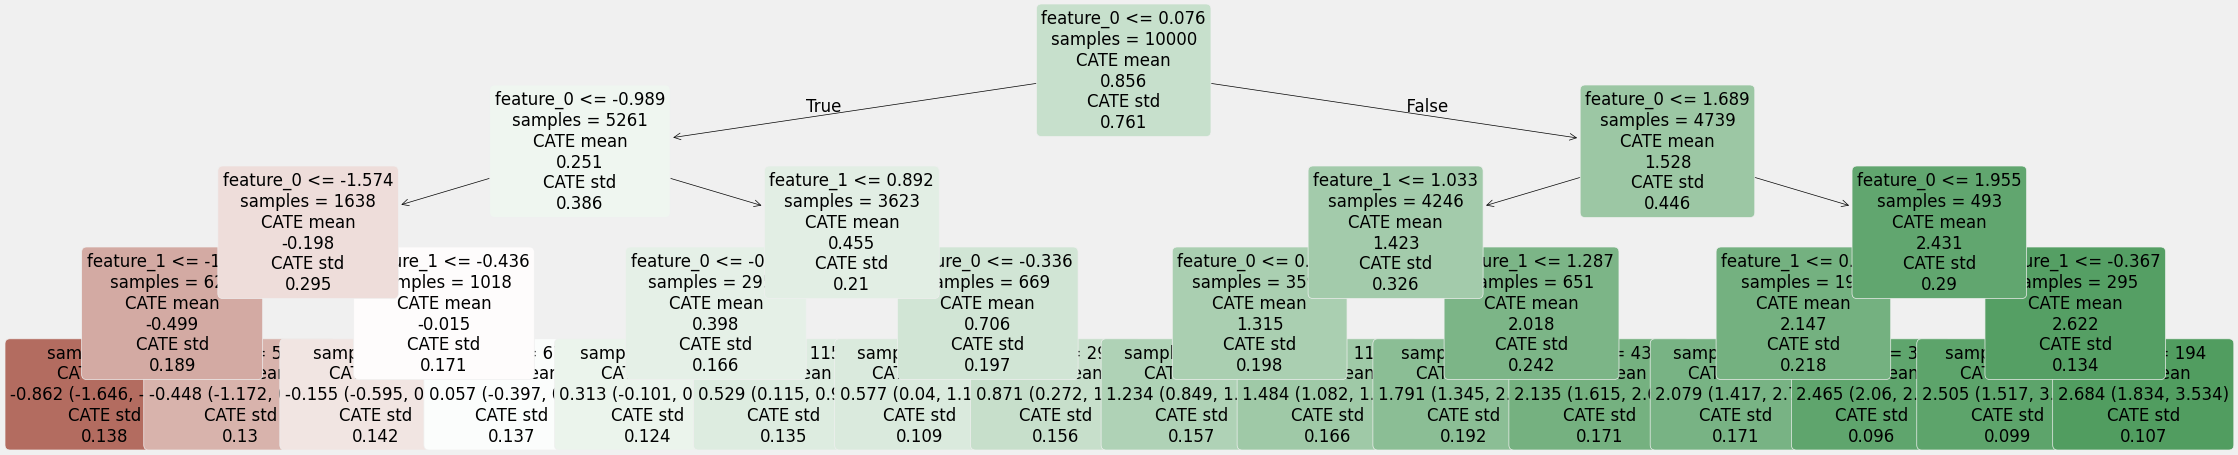

In [3]:
cf = CF(data)
cf.fit(criterion='mse', n_estimators=500)
cf.single_tree_interpreter(print_tree=True)

In [4]:
important_features = []
for i, fi in enumerate(cf.forest.feature_importances_):
    if fi > 0.05:
        print(data.df.columns[i], round(fi,2))
        important_features.append(i)

feature_0 0.92
feature_1 0.05


<Axes: xlabel='feature_0', ylabel='feature_1'>

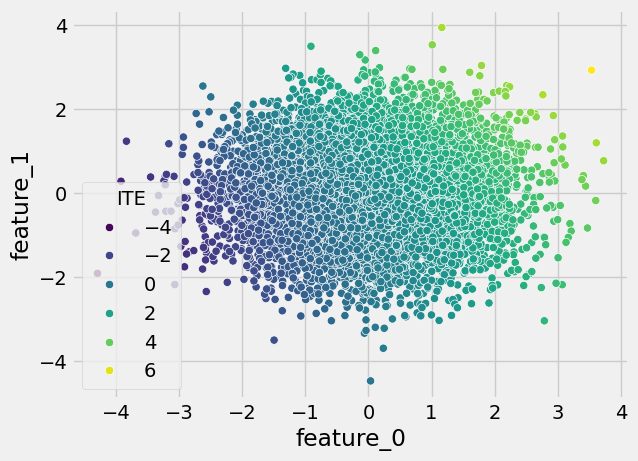

In [5]:
sns.scatterplot(data=data.df, x='feature_0', y='feature_1', hue=data.df['ITE'], palette='viridis')

In [6]:
import ipywidgets as widgets
sliders = []
for i in range(10):
    sliders.append(widgets.FloatRangeSlider(
        value=[data.df[data.df.columns[i]].min(), data.df[data.df.columns[i]].max()],
        min=data.df[data.df.columns[i]].min(),
        max=data.df[data.df.columns[i]].max(),
        step=0.1,
        description=data.df.columns[i],
        disabled=False,
        continuous_update=False,
        orientation='horizontal',
        readout=True,
        readout_format='.1f',
    ))


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact

@interact(
    feature_0=sliders[0],
    feature_1=sliders[1],
    feature_2=sliders[2],
    feature_3=sliders[3],
    feature_4=sliders[4],
    feature_5=sliders[5],
    feature_6=sliders[6],
    feature_7=sliders[7],
    feature_8=sliders[8],
    feature_9=sliders[9]
)
def plot_feature(feature_0, feature_1, feature_2, feature_3, feature_4, feature_5, feature_6, feature_7, feature_8, feature_9):
    
    cond = ""
    for i in range(len(sliders)):
        if cond !="":
            cond += " and "
        cond += f' {data.df.columns[i]} > {sliders[i].value[0]} and {data.df.columns[i]} < {sliders[i].value[1]}'

    query_data = data.execute(cond)
    s = query_data.shape[0] / data.df.shape[0]
    

    sns.scatterplot(data=query_data, x='feature_0', y='feature_1', hue=query_data['ITE'], palette='viridis')
    # make the x-axis have fixed x ticks
    plt.xticks(np.arange(-4, 4, 0.5))
    plt.yticks(np.arange(-4, 4, 0.5))
    plt.xlabel('feature_0')
    plt.ylabel('feature_1')
    plt.title(f'Heatmap of τ(x), s={s}')
    plt.show()

interactive(children=(FloatRangeSlider(value=(-4.295390984068005, 3.7278333447631873), continuous_update=False…

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact

@interact(
    feature_0=sliders[0],
    feature_1=sliders[1],
    feature_2=sliders[2],
    feature_3=sliders[3],
    feature_4=sliders[4],
    feature_5=sliders[5],
    feature_6=sliders[6],
    feature_7=sliders[7],
    feature_8=sliders[8],
    feature_9=sliders[9]
)
def plot_feature(feature_0, feature_1, feature_2, feature_3, feature_4, feature_5, feature_6, feature_7, feature_8, feature_9):
    
    cond = ""
    for i in range(len(sliders)):
        if cond !="":
            cond += " and "
        cond += f' {data.df.columns[i]} > {sliders[i].value[0]} and {data.df.columns[i]} < {sliders[i].value[1]}'

    query_data = data.execute(cond)
    s = query_data.shape[0] / data.df.shape[0]
    
    bins = 10

    # Example data (replace with your actual data)
    x = query_data['feature_0'].to_numpy()  # Replace with your x data
    y = query_data['feature_1'].to_numpy()  # Replace with your y data
    d = query_data['ITE'].to_numpy()   # Replace with your density data


    # Bin the data
    x_bins = np.linspace(data.df['feature_0'].min(), data.df['feature_0'].max(), bins)  
    y_bins = np.linspace(data.df['feature_1'].min(), data.df['feature_1'].max(), bins)  

    x_binned = np.digitize(x, bins=x_bins) - 1
    y_binned = np.digitize(y, bins=y_bins) - 1

    # Create a DataFrame to easily group and aggregate the data
    df = pd.DataFrame({'x_bin': x_binned, 'y_bin': y_binned, 'density': d})

    # Calculate the mean density for each bin combination
    heatmap_data = df.groupby(['y_bin', 'x_bin']).density.mean().unstack()

    heatmap_data = heatmap_data.reindex(index=np.arange(len(y_bins) - 1), columns=np.arange(len(x_bins) - 1))


    # Plotting the heatmap
    plt.figure(figsize=(5, 5))
    plt.imshow(heatmap_data, origin='lower', cmap='viridis', aspect='auto')
    plt.colorbar(label='τ(x)')
    plt.xlabel('feature_0')
    plt.ylabel('feature_1')
    plt.title(f'Heatmap of τ(x) by binned x and y, s={s}')
    plt.xticks(ticks=np.arange(len(x_bins)), labels=[round(x,1) for x in x_bins], rotation=45)
    plt.yticks(ticks=np.arange(len(y_bins)), labels=[round(x,1) for x in y_bins], rotation=45)
    # plt.xticks(ticks=np.arange(len(x_bins) - 1), labels=[f'{x_bins[i]:.2f}-{x_bins[i+1]:.2f}' for i in range(len(x_bins) - 1)], rotation=45)
    # plt.yticks(ticks=np.arange(len(y_bins) - 1), labels=[f'{y_bins[i]:.2f}-{y_bins[i+1]:.2f}' for i in range(len(y_bins) - 1)])

    plt.show()

interactive(children=(FloatRangeSlider(value=(-4.295390984068005, 3.7278333447631873), continuous_update=False…